In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

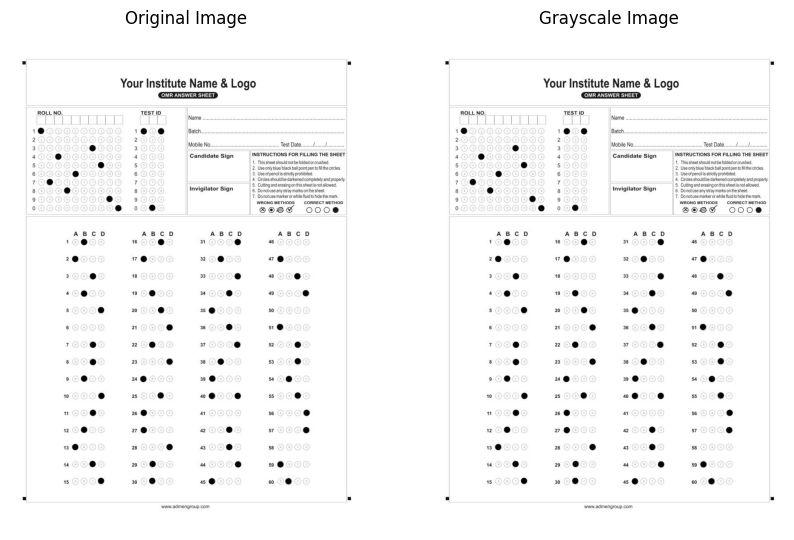

In [ ]:
img = cv2.imread('../images/image2.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Grayscale Image')
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()

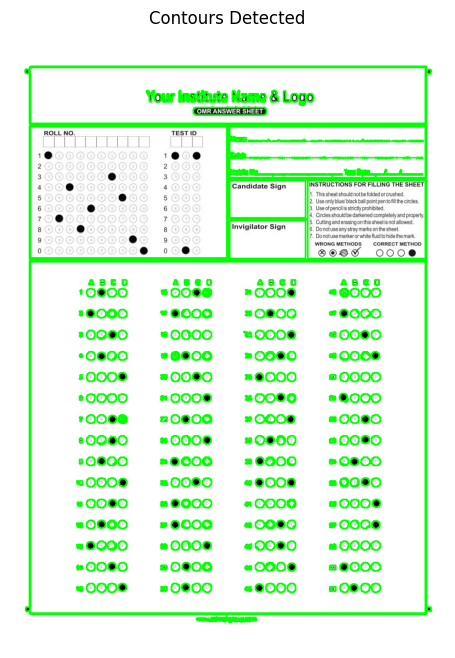

In [ ]:
edged = cv2.Canny(gray, 50, 150)
contours, _ = cv2.findContours(edged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#show contours
contour_img = img.copy()
cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)
plt.figure(figsize=(10, 8))
plt.title('Contours Detected')
plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

Duplicated version

Saved section_1.png at [35, 416, 722, 643]


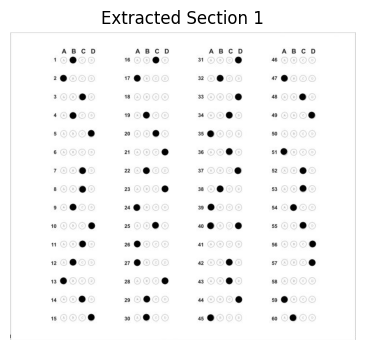

Saved section_2.png at [399, 343, 139, 70]


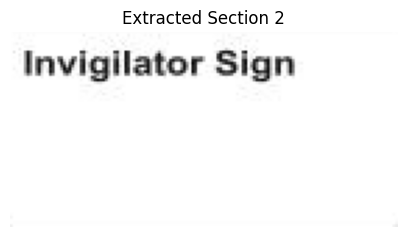

Saved section_3.png at [399, 270, 139, 69]


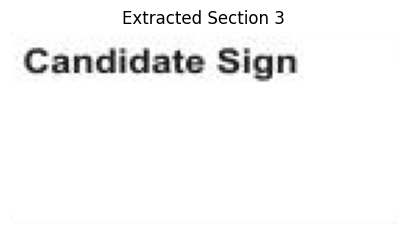

Saved section_4.png at [399, 269, 359, 146]


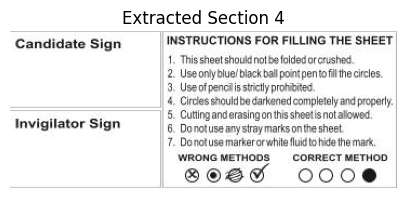

Saved section_5.png at [399, 172, 357, 94]


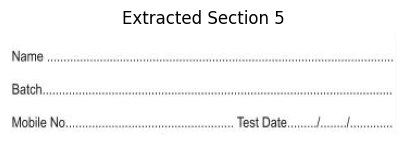

Saved section_6.png at [37, 172, 358, 240]


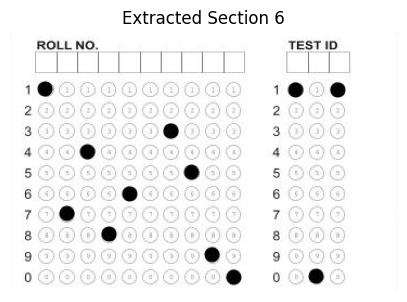

Saved section_7.png at [398, 170, 360, 97]


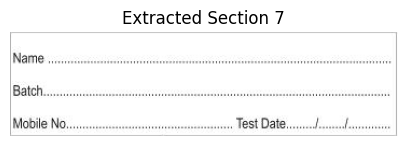

Saved section_8.png at [35, 170, 361, 244]


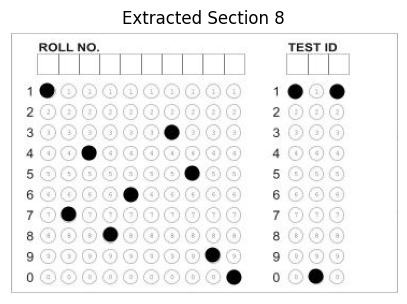

Saved section_9.png at [37, 77, 721, 92]


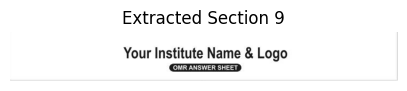

Saved section_10.png at [37, 64, 719, 103]


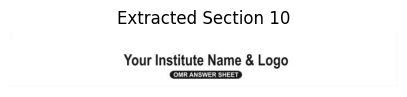

Extraction complete.


In [ ]:
section_count = 0
for cnt in contours:
    # Approximate the contour to see if it's a rectangle
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
    
    # get bounding box coordinates
    x, y, w, h = cv2.boundingRect(approx)
    
    # Filter by size
    if w > 100 and h > 50:
        section_count += 1
        roi = img[y:y+h, x:x+w]
        # cv2.imwrite(f'sections/section_{section_count}.png', roi) # Uncomment to save the extracted sections
        print(f"Saved section_{section_count}.png at [{x}, {y}, {w}, {h}]")

        plt.figure(figsize=(5, 4))
        plt.title(f'Extracted Section {section_count}')
        plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()


print("Extraction complete.")

Fixed Duplicated version

In [ ]:
# Using intersection over union (IoU) to filter out overlapping boxes

Saved section_1.png at [37, 172, 358, 240]


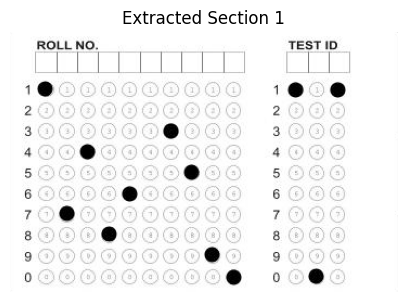

Saved section_2.png at [399, 269, 359, 146]


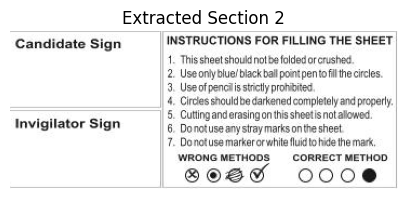

Saved section_3.png at [399, 343, 139, 70]


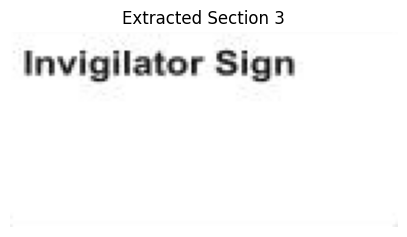

Saved section_4.png at [399, 270, 139, 69]


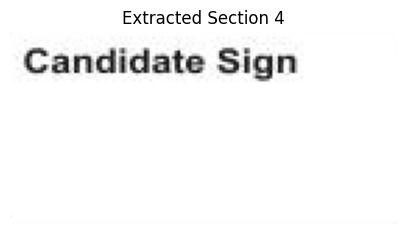

Saved section_5.png at [35, 416, 723, 643]


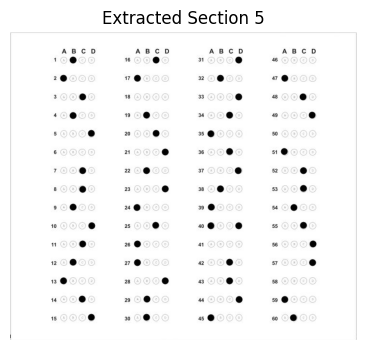

Saved section_6.png at [399, 172, 357, 94]


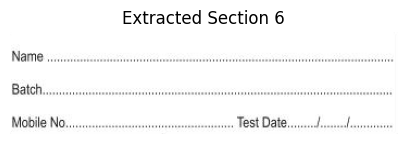

Saved section_7.png at [37, 64, 719, 103]


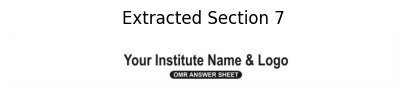

In [ ]:
# sort contours by area (largest first na)
contours = sorted(contours, key=lambda c: cv2.contourArea(c), reverse=True)

section_count = 0
saved_sections = [] 
threshold = 25 # tolerance for shifts

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    
    if w > 100 and h > 50:
        is_duplicate = False
        
        for (sx, sy, sw, sh) in saved_sections:
            # RULE: If the box starts at the same place & is roughly the same size
            same_start = abs(x - sx) < threshold and abs(y - sy) < threshold
            same_size = abs(w - sw) < threshold and abs(h - sh) < threshold
            
            if same_start and same_size:
                is_duplicate = True
                break
        
        if is_duplicate:
            continue 

        # Success: Add to saved list and extract
        saved_sections.append((x, y, w, h))
        section_count += 1
        
        roi = img[y:y+h, x:x+w]
        cv2.imwrite(f'sections/section_{section_count}.png', roi)
        print(f"Saved section_{section_count}.png at [{x}, {y}, {w}, {h}]")

        plt.figure(figsize=(5, 4))
        plt.title(f'Extracted Section {section_count}')
        plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()